In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import RegularGridInterpolator
plt.style.use("../figures.mplstyle")
from matplotlib.colors import LogNorm

In [2]:
overburden_data = pd.read_csv("overburden_horizon.csv",comment="#",skipinitialspace=True)

In [3]:
overburden_interp = RegularGridInterpolator((overburden_data["theta_deg"].unique(), overburden_data["phi_deg"].unique()),
                                            overburden_data.pivot(index="theta_deg", columns="phi_deg", values="X_gcm2").values,
                                            fill_value=0, bounds_error=False)

In [4]:
N = 1000
theta_range = np.linspace(65,92,N)
phi_range = np.linspace(0,358,N)
theta_grid, phi_grid = np.meshgrid(theta_range, phi_range)
points = np.array([theta_grid.flatten(), phi_grid.flatten()]).T
overburden_values = overburden_interp(points)

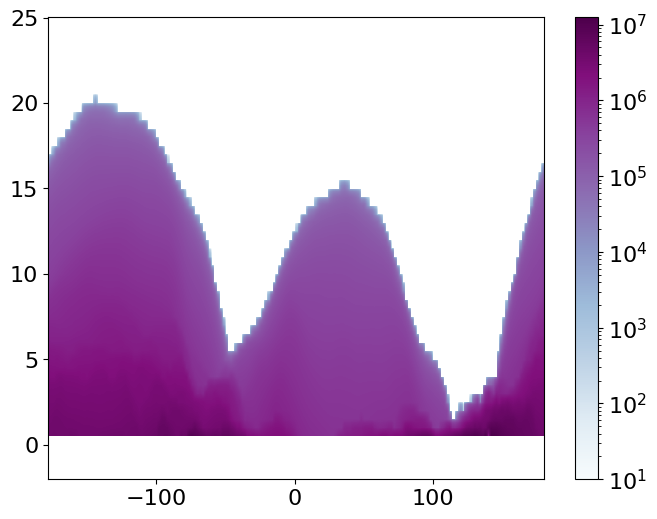

In [5]:
plt.pcolormesh(180-phi_grid, 90-theta_grid, overburden_values.reshape(theta_grid.shape), shading='auto',norm=LogNorm(vmin=1e1))
plt.colorbar()

# Cosmic-ray rate in SINE with the Jura overburden

The cosmic-muon background for SINE (arXiv:2501.08278) was first estimated in
[`SurfaceMuonBackgroundEstimate.ipynb`](SurfaceMuonBackgroundEstimate.ipynb) with
**EcoMug**, assuming a **featureless Earth** (an open $\cos^n\theta$ sky). In reality the
**Jura** mountains partially shield cosmic rays arriving from some azimuths. The slant
rock overburden around SINE was ray-traced in
[`compute_overburden.jl`](../../CORSIKA-terrain/scripts/compute_overburden.jl) and loaded
above from `overburden_horizon.csv`.

The sections below combine that overburden map with a cosmic-muon flux to (1) build a
per-direction muon **survival probability**, (2) **reweight** the existing EcoMug sample to
get a Jura-corrected post-cut background rate, and (3) show the **azimuthal distribution**
of surviving cosmic muons relative to the CMS→SINE beam. *(All existing files are left
unmodified; this analysis only adds to this notebook.)*

In [6]:
import sys
geneva_dir = "/n/holylfs05/LABS/arguelles_delgado_lab/Everyone/nkamp/Geneva/Lake_Geneva_Neutrinos/"
sys.path.append(geneva_dir)
from GeometryHelpers import Circle, lat_long_to_xyz   # lightweight geometry helpers

cosmic_color = "seagreen"

# muon range in rock [m] for energy E [GeV] at density rho [g/cm^3]
# (re-implemented from MuonSimulationHelpers.py:80 to avoid the heavy SIREN import)
def muon_range(E, rho=1):
    return 1.0/(rho*5e-4) * np.log(1 + 2e-3*E)

# overburden lookup wrapper around the interpolator built above (handles grid edges)
def lookup_overburden(theta_z_deg, phi_enu_deg):
    th = np.asarray(theta_z_deg, float)
    ph = np.asarray(phi_enu_deg, float) % 360.0
    ph = np.clip(ph, 0.0, 358.0)              # grid covers 0..358 deg
    X = overburden_interp(np.stack([np.clip(th, 65.0, 89.5), ph], axis=-1))
    return np.where(th < 65.0, 0.0, X)        # overhead directions: ~no rock

# ---- rate normalisation, mirrored from SurfaceMuonBackgroundEstimate.ipynb ----
rate = 178282/2          # MuonSimOut.txt; /2 for "hitting near panel first"
Ngen = 100000000
rate *= 3                # three detectors
n_bunches = 72 * ((3 + 3 + 4)*3 + (3 + 3 + 3))
cycle_time = 88924       # ns
duty_factor = 25*n_bunches / cycle_time
eff_duty_factor = 2.5/25 * duty_factor   # beam-timing cut
rate *= eff_duty_factor
c = 3e-1                 # m/ns
n_months_HLLHC = 58
n_seconds_HLLHC = n_months_HLLHC * 30.5 * 24 * 60 * 60

# ---- LHC geometry (same construction as MuonSimulationHelpers.py) ----
LHC_data = pd.read_parquet(geneva_dir + "Data/LHC_data.parquet")
LHC = Circle(np.array(LHC_data.loc["Point4", ["X", "Y", "Z"]], dtype=float),
             np.array(LHC_data.loc["LHCb",   ["X", "Y", "Z"]], dtype=float),
             np.array(LHC_data.loc["Point6", ["X", "Y", "Z"]], dtype=float))
for k in list(LHC_data.index):
    elev, _ = LHC.find_elevation(*np.array(LHC_data.loc[k, ["Latitude", "Longitude"]], dtype=float))
    LHC_data.loc[k, "Elevation"] = elev
    LHC_data.loc[k, ["X", "Y", "Z"]] = lat_long_to_xyz(
        *np.array(LHC_data.loc[k, ["Latitude", "Longitude", "Elevation"]], dtype=float))

# Identify the CMS interaction point (LHC Point 5); the SIREN sample is "SINE_CMS_West"
_cands = [k for k in LHC_data.index if str(k).upper() in ("CMS", "POINT5")]
assert _cands, f"No CMS/Point5 key in LHC_data.index = {list(LHC_data.index)}"
CMS_key = _cands[0]
print("LHC interaction points:", list(LHC_data.index))

LHC interaction points: ['ATLAS', 'ALICE', 'Point3', 'Point4', 'CMS', 'Point6', 'Point7', 'LHCb']


## Coordinate frames and the beam azimuth

Three frames are involved:

| Frame | axes | zenith $\theta$ | azimuth $\phi$ |
|-------|------|-----------------|----------------|
| **Overburden (ENU)** — `overburden_horizon.csv` | x=East, y=North, z=Up | from vertical | CCW from **East** |
| **EcoMug / detector** — `MuonSimOut.txt`, `EcoRunner.cxx` | x=beam (panel normal), y=panel width, z=Up | momentum dir from +z | CCW from the **beam** axis |
| **ECEF** — `LHC_data` | geocentric x,y,z | — | — |

Both physics frames share **z = Up**, so they differ only by a rotation about the vertical
by the **beam azimuth** $\alpha$ — the bearing of the CMS→SINE beam projected into the
detector ENU frame. We obtain $\alpha$ from the LHC-circle tangent at the CMS interaction
point (reusing `GeometryHelpers`), giving the single number needed to map a muon's
beam-frame direction to the ENU overburden map: $\phi_{\rm ENU}=\phi_{\rm beam}+\alpha$.

In [7]:
# Detector ENU basis (origin = SINE centroid, from the overburden_horizon.csv header)
det_ecef = np.array([4.3758338841576995e6, 447476.8376059988, 4.6097685961005045e6])
Up    = det_ecef / np.linalg.norm(det_ecef)
East  = np.cross([0, 0, 1.0], Up); East /= np.linalg.norm(East)
North = np.cross(Up, East)

# Beam tangent at the CMS interaction point, oriented from CMS toward SINE
beam_pos = np.array(LHC_data.loc[CMS_key, ["X", "Y", "Z"]], dtype=float)
beam_dir = LHC.tangent_line(beam_pos)
if np.dot(beam_dir, det_ecef - beam_pos) < 0:
    beam_dir = -beam_dir

# Project into ENU -> azimuth (CCW from East) and elevation of the beam
alpha     = np.degrees(np.arctan2(np.dot(beam_dir, North), np.dot(beam_dir, East)))
beam_elev = np.degrees(np.arcsin(np.clip(np.dot(beam_dir, Up), -1, 1)))
print(f"CMS interaction point key: {CMS_key}")
print(f"Beam azimuth  alpha = {alpha % 360:.1f} deg (CCW from East)")
print(f"Beam elevation      = {beam_elev:.2f} deg (negative = pointing below horizon)")

CMS interaction point key: CMS
Beam azimuth  alpha = 168.3 deg (CCW from East)
Beam elevation      = 1.00 deg (negative = pointing below horizon)


## Cosmic flux, energy loss, and the survival probability

A muon arriving from zenith angle $\theta_z$ through a slant rock column $X$ (g/cm²)
reaches the detector only if its surface energy exceeds the minimum needed to traverse
that column. We:

1. parameterise the sea-level flux $\Phi(E,\theta_z)$ with the standard **Gaisser/Guan**
   modified-Gaisser formula (Chirkin $\cos\theta^\*$ curvature correction);
2. get the minimum surface energy by **inverting the project's `muon_range`**,
   $X = \rho\,R(E)\,100$ with $R(E)=\tfrac{1}{\rho\,5\!\times\!10^{-4}}\ln(1+2\!\times\!10^{-3}E)$,
   giving the density-independent $E_{\min}(X)=\big(e^{5\times10^{-6}X}-1\big)/2\times10^{-3}$ GeV;
3. define the per-direction **survival probability**
   $w(\theta_z,X)=\dfrac{\int_{E_{\min}}^{\infty}\Phi\,dE}{\int_{E_{\rm thr}}^{\infty}\Phi\,dE}$,
   with $E_{\rm thr}$ the EcoMug generation floor ($p_{\min}=0.01$ GeV/c). $w=1$ where
   $X=0$ and $\to 0$ for thick rock.

In [8]:
from scipy.integrate import quad

# ---- Gaisser/Guan sea-level muon flux  [GeV^-1 m^-2 s^-1 sr^-1] ----
# Guan et al. (arXiv:1509.06176): modified Gaisser parametrisation with the
# Chirkin cos(theta*) correction for Earth curvature (valid down to low E / large angle).
_P = (0.102573, -0.068287, 0.958633, 0.0407253, 0.817285)
def cos_theta_star(cz):
    cz = np.clip(cz, 0, 1)
    num = cz**2 + _P[0]**2 + _P[1]*cz**_P[2] + _P[3]*cz**_P[4]
    return np.sqrt(num / (1 + _P[0]**2 + _P[1] + _P[3]))

def gaisser_guan(E, theta_z_rad):
    cs = cos_theta_star(np.cos(theta_z_rad))
    return 1e4 * 0.14 * E**(-2.7) * (1.0/(1 + 1.1*E*cs/115.0)
                                     + 0.054/(1 + 1.1*E*cs/850.0))   # 1e4: cm^-2 -> m^-2

# ---- minimum surface energy to cross a slant rock column X [g/cm^2] ----
# Invert muon_range(E, rho) = 1/(rho*5e-4) * ln(1 + 2e-3 E)  (MuonSimulationHelpers.py).
# Since X = rho * range_m * 100, the threshold is density-independent:
def E_min_from_X(X_gcm2):
    return (np.exp(5e-6 * np.asarray(X_gcm2, float)) - 1.0) / 2e-3   # GeV

# ---- survival probability: fraction of the (E>E_thr) flux above E_min ----
m_mu   = 0.105658
p_min  = 0.01                              # EcoMug default minimum momentum [GeV/c]
E_thr  = np.sqrt(p_min**2 + m_mu**2)       # ~0.106 GeV, the generation floor
E_max  = 1000.0                            # EcoMug default maximum momentum

def survival_fraction(theta_z_deg, X_gcm2):
    th = np.radians(theta_z_deg)
    Emin = max(E_min_from_X(X_gcm2), E_thr)
    denom = quad(gaisser_guan, E_thr, E_max, args=(th,), limit=100)[0]
    numer = quad(gaisser_guan, Emin,  E_max, args=(th,), limit=100)[0]
    return numer/denom if denom > 0 else 0.0

# Precompute w on a (zenith, log10 X) grid and build an interpolator
th_grid   = np.linspace(0, 90, 46)
logX_grid = np.linspace(0, 7, 71)          # X from 1 to 1e7 g/cm^2
Wgrid = np.array([[survival_fraction(t, 10**lx) for lx in logX_grid] for t in th_grid])
survival_interp = RegularGridInterpolator((th_grid, logX_grid), Wgrid,
                                          bounds_error=False, fill_value=None)

# ---- sanity checks ----
print("E_min(0 g/cm^2)      =", f"{E_min_from_X(0.0):.3g} GeV")
print("E_min(1e3 g/cm^2)    =", f"{E_min_from_X(1e3):.3g} GeV")
print("E_min(1e5 g/cm^2)    =", f"{E_min_from_X(1e5):.3g} GeV")
# round-trip against the analytic range (rho=2.65): muon_range(E_min)*rho*100 should give X
for X in (1e2, 1e4, 1e6):
    assert np.isclose(muon_range(E_min_from_X(X), 2.65)*2.65*100, X, rtol=1e-6)
print("E_min(X) inverts muon_range correctly.")



/tmp/ipykernel_1791441/3768132.py:33: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  numer = quad(gaisser_guan, Emin,  E_max, args=(th,), limit=100)[0]


E_min(0 g/cm^2)      = 0 GeV
E_min(1e3 g/cm^2)    = 2.51 GeV
E_min(1e5 g/cm^2)    = 324 GeV
E_min(X) inverts muon_range correctly.


/tmp/ipykernel_1791441/3768132.py:33: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  numer = quad(gaisser_guan, Emin,  E_max, args=(th,), limit=100)[0]


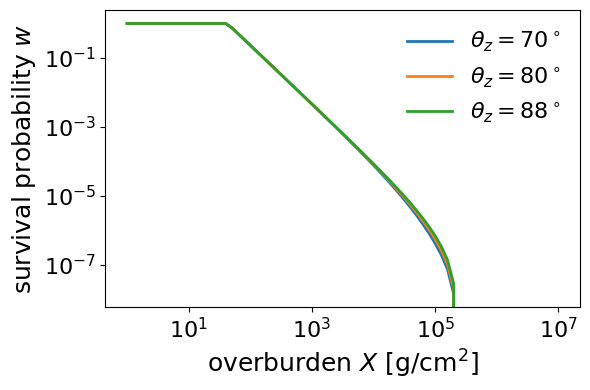

In [9]:
plt.figure(figsize=(6,4))
for tz in (70, 80, 88):
    plt.plot(10**logX_grid,
             [survival_fraction(tz, 10**lx) for lx in logX_grid],
             label=f"$\\theta_z={tz}^\\circ$")
plt.xscale("log"); plt.xlabel("overburden $X$ [g/cm$^2$]")
plt.yscale("log"); plt.ylabel("survival probability $w$")
plt.legend(); plt.tight_layout(); plt.show()

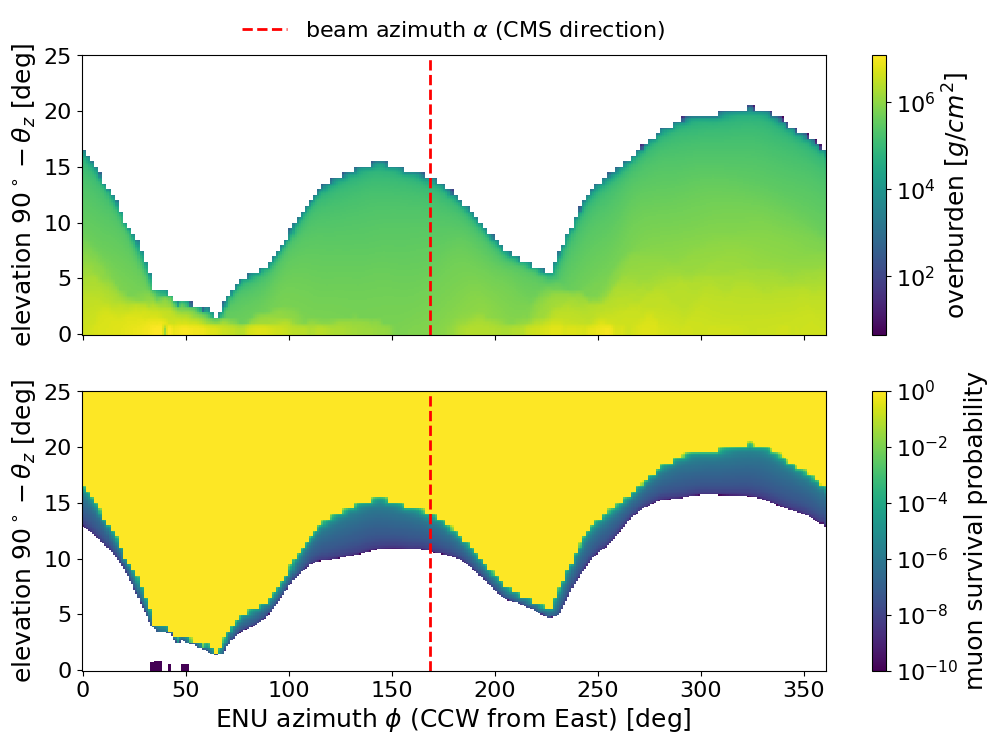

In [48]:
# Survival probability w(theta_z, phi_ENU) across the horizon band.
from matplotlib.patches import bbox_artist


th_plot  = np.linspace(65, 90, 200)
phi_plot = np.linspace(0, 360, 360)
TH, PH = np.meshgrid(th_plot, phi_plot)
Xg = lookup_overburden(TH.ravel(), PH.ravel())
Wg = np.ones_like(Xg)
mg = Xg > 1.0
Wg[mg] = survival_interp(np.stack([np.clip(TH.ravel()[mg], 0, 90), np.log10(Xg[mg])], axis=-1))
Wg = np.clip(Wg, 0, 1).reshape(TH.shape)

fig,ax = plt.subplots(2,1,figsize=(12,8),sharex=True, sharey=True)
mappable = ax[0].pcolormesh(PH, 90-TH, Xg.reshape(TH.shape), shading="auto", cmap="viridis", norm=LogNorm())
plt.colorbar(mappable, label=r"overburden [$g/cm^2$]")
ax[0].axvline(alpha % 360, color="r", ls="--", label="beam azimuth $\\alpha$ (CMS direction)")
ax[0].set_ylabel("elevation $90^\\circ-\\theta_z$ [deg]")
ax[0].legend(bbox_to_anchor=(0.5, 1.2), loc="upper center")

mappable = ax[1].pcolormesh(PH, 90-TH, Wg, shading="auto", cmap="viridis", norm=LogNorm(vmin=1e-10))
plt.colorbar(mappable, label="muon survival probability")
ax[1].axvline(alpha % 360, color="r", ls="--", label="beam azimuth $\\alpha$ (CMS direction)")
ax[1].set_xlabel("ENU azimuth $\\phi$ (CCW from East) [deg]")
ax[1].set_ylabel("elevation $90^\\circ-\\theta_z$ [deg]")

plt.show()

## Reweighting the EcoMug background and applying the cuts

We now load the featureless EcoMug coincidence sample (`MuonSimOut.txt`), assign each muon
its survival weight `w`, and re-derive the post-cut cosmic rate using the **same**
normalisation and cut chain as
[`SurfaceMuonBackgroundEstimate.ipynb`](SurfaceMuonBackgroundEstimate.ipynb). The
featureless rate counts muons (`w = 1`); the Jura-shielded rate sums the survival weights.

In [11]:
# ---- load the featureless EcoMug coincidence sample ----
mu = pd.read_csv("MuonSimOut.txt", sep=r"\s+")
cosmic = mu.query("hitboth==1").copy()

# Muon momentum direction (dx,dy,dz) is in the EcoMug frame: x=beam, y=panel width, z=Up.
# The *source* (sky) direction is -(dx,dy,dz). Rotate its horizontal part by the beam
# azimuth alpha to get the ENU components, then read off zenith / ENU azimuth.
a  = np.radians(alpha)
dx, dy, dz = cosmic["dx"].values, cosmic["dy"].values, cosmic["dz"].values
sE = np.cos(a)*(-dx) - np.sin(a)*(-dy)
sN = np.sin(a)*(-dx) + np.cos(a)*(-dy)
sU = -dz
cosmic["theta_z"]        = np.degrees(np.arccos(np.clip(sU, -1, 1)))   # sky zenith from vertical
cosmic["phi_enu"]        = np.degrees(np.arctan2(sN, sE)) % 360         # azimuth CCW from East
cosmic["phi_beam_source"] = (np.degrees(np.arctan2(-dy, -dx))) % 360    # azimuth CCW from beam x-axis

# ---- overburden, minimum surface energy, and survival weight per muon ----
cosmic["X_gcm2"] = lookup_overburden(cosmic["theta_z"], cosmic["phi_enu"])
cosmic["E_min"]  = E_min_from_X(cosmic["X_gcm2"].values)
w = np.ones(len(cosmic))
m = cosmic["X_gcm2"].values > 1.0
w[m] = survival_interp(np.stack([np.clip(cosmic["theta_z"].values[m], 0, 90),
                                 np.log10(cosmic["X_gcm2"].values[m])], axis=-1))
cosmic["w"] = np.clip(w, 0.0, 1.0)

# Azimuth (in the beam frame) of the peak Jura overburden, for plotting
_near_horizon = overburden_data.query("theta_deg >= 88")
jura_phi_enu  = _near_horizon.loc[_near_horizon["X_gcm2"].idxmax(), "phi_deg"]
jura_phi_beam = (jura_phi_enu - alpha) % 360

print(f"Coincidence muons: {len(cosmic):,}")
print(f"Fraction with non-negligible overburden (X>1 g/cm^2): {m.mean():.3f}")
print(f"Mean survival weight over the sample: {cosmic['w'].mean():.3f}")
print(f"Peak Jura overburden at ENU azimuth {jura_phi_enu:.0f} deg  "
      f"(phi_beam = {jura_phi_beam:.0f} deg)")
# Sanity: directions with zero overburden must have w == 1
assert np.allclose(cosmic.loc[cosmic['X_gcm2']==0, 'w'], 1.0)

Coincidence muons: 1,870,483
Fraction with non-negligible overburden (X>1 g/cm^2): 0.109
Mean survival weight over the sample: 0.891
Peak Jura overburden at ENU azimuth 38 deg  (phi_beam = 230 deg)


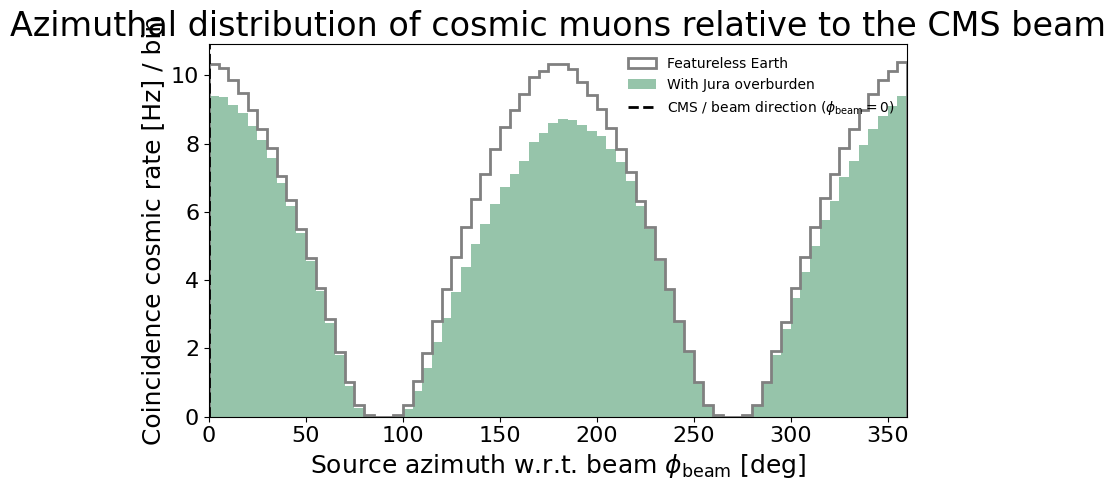

In [12]:
# Azimuthal distribution of coincidence cosmic muons w.r.t. the beam (CMS) direction.
# phi_beam = 0 is the direction the beam/neutrinos point (toward which the panel normal lies);
# the source azimuth is measured CCW from that axis in the horizontal plane.
abins = np.linspace(0, 360, 73)
plt.figure(figsize=(8,5))
plt.hist(cosmic["phi_beam_source"], bins=abins,
         weights=np.full(len(cosmic), rate/Ngen),
         histtype="step", lw=2, color="grey", label="Featureless Earth")
plt.hist(cosmic["phi_beam_source"], bins=abins,
         weights=cosmic["w"]*rate/Ngen,
         histtype="stepfilled", alpha=0.5, color=cosmic_color, label="With Jura overburden")
plt.axvline(0,   color="k",   ls="--", label=r"CMS / beam direction ($\phi_{\rm beam}=0$)")
#plt.axvline(jura_phi_beam, color="saddlebrown", ls=":", lw=2, label="Peak Jura overburden")
plt.xlabel(r"Source azimuth w.r.t. beam $\phi_{\rm beam}$ [deg]")
plt.ylabel("Coincidence cosmic rate [Hz] / bin")
plt.xlim(0,360); plt.legend(fontsize=10)
plt.title("Azimuthal distribution of cosmic muons relative to the CMS beam")
plt.tight_layout()
plt.show()

In [13]:
# ---- first/second plane bookkeeping + displacement variables (as in source nb) ----
cosmic = cosmic.copy()
cosmic["first_plane"] = np.array(cosmic.t1 > cosmic.t2, dtype=int) + 1
for coord in ["x", "y", "z"]:
    cosmic["first_plane_%s"%coord]  = np.where(cosmic.first_plane==1, cosmic["int1_%s"%coord], cosmic["int2_%s"%coord])
    cosmic["second_plane_%s"%coord] = np.where(cosmic.first_plane==1, cosmic["int2_%s"%coord], cosmic["int1_%s"%coord])
cosmic["delta_t"] = np.sqrt((cosmic.int2_x-cosmic.int1_x)**2 +
                            (cosmic.int2_y-cosmic.int1_y)**2 +
                            (cosmic.int2_z-cosmic.int1_z)**2) / c
cosmic["muon_height_difference"]  = cosmic["second_plane_z"] - cosmic["first_plane_z"]
cosmic["horizontal_displacement"] = cosmic["second_plane_y"] - cosmic["first_plane_y"]
cosmic["vertical_displacement"]   = cosmic["second_plane_z"] - cosmic["first_plane_z"]

# ---- cut definitions (identical to source notebook) ----
vertical_cut_2D = -0.04
opening_angle   = 2
slope = 1./np.arctan(opening_angle/2)

stages = {
    "No Cuts"           : cosmic,
    "Panel $\\Delta t$" : cosmic.query("delta_t > 8 and delta_t < 10"),
}
stages["Conservative 1D"] = stages["Panel $\\Delta t$"].query("muon_height_difference >= -0.02")
stages["Aggressive 1D"]   = stages["Panel $\\Delta t$"].query("muon_height_difference >=  0.02")
stages["2D Cut"]          = stages["Panel $\\Delta t$"].query(
    "vertical_displacement > @slope*abs(horizontal_displacement) + @vertical_cut_2D")

# ---- featureless (count) vs shielded (sum of survival weights) rates ----
rate_table = {}
for label, sub in stages.items():
    n_feat = len(sub)
    n_shld = float(sub["w"].sum())
    rate_table[label] = dict(
        featureless_Hz = n_feat * rate/Ngen,
        shielded_Hz    = n_shld * rate/Ngen,
        suppression    = (n_shld/n_feat) if n_feat else np.nan,
        feat_yield_HLLHC = n_feat * rate/Ngen * n_seconds_HLLHC,
        shld_yield_HLLHC = n_shld * rate/Ngen * n_seconds_HLLHC,
    )

print(f"Effective duty factor = {eff_duty_factor:.4f}\n")
print(f"{'stage':<18}{'featureless [Hz]':>18}{'shielded [Hz]':>16}{'survival':>11}")
for label, r in rate_table.items():
    print(f"{label:<18}{r['featureless_Hz']:>18.4g}{r['shielded_Hz']:>16.4g}{r['suppression']:>11.3f}")
print(f"\nOverall Jura suppression of the No-Cuts coincidence rate: "
      f"{rate_table['No Cuts']['suppression']:.3f}")
print(f"58-month HL-LHC cosmic yield after 2D cut: "
      f"featureless {rate_table['2D Cut']['feat_yield_HLLHC']:.2g}  ->  "
      f"Jura-shielded {rate_table['2D Cut']['shld_yield_HLLHC']:.2g}")

Effective duty factor = 0.0789

stage               featureless [Hz]   shielded [Hz]   survival
No Cuts                        394.9           351.8      0.891
Panel $\Delta t$               134.8           104.6      0.776
Conservative 1D               0.1121               0      0.000
Aggressive 1D                      0               0        nan
2D Cut                      0.002322               0      0.000

Overall Jura suppression of the No-Cuts coincidence rate: 0.891
58-month HL-LHC cosmic yield after 2D cut: featureless 3.5e+05  ->  Jura-shielded 0


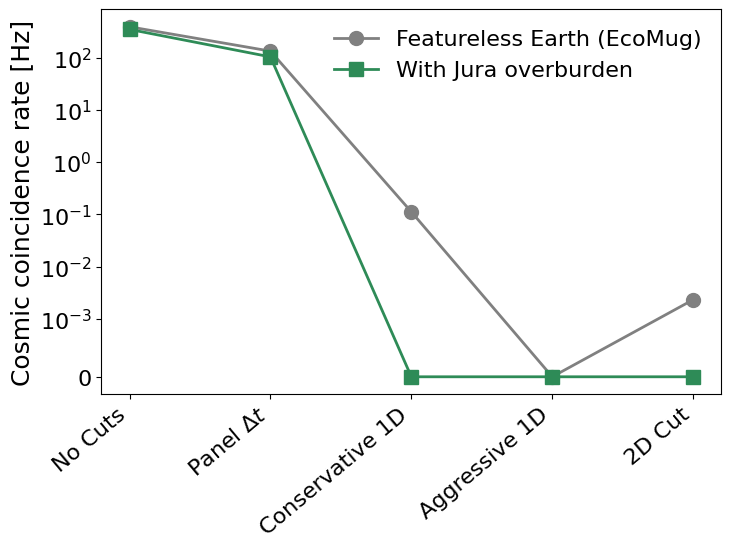

In [14]:
# Cosmic rate vs cut stage: featureless Earth vs Jura-shielded
stage_labels = list(rate_table.keys())
feat = np.array([rate_table[s]["featureless_Hz"] for s in stage_labels])
shld = np.array([rate_table[s]["shielded_Hz"]    for s in stage_labels])

plt.figure(figsize=(8,5))
plt.plot(stage_labels, feat, "o-", color="grey",      label="Featureless Earth (EcoMug)")
plt.plot(stage_labels, shld, "s-", color=cosmic_color, label="With Jura overburden")
plt.yscale("symlog", linthresh=1e-3)
plt.ylabel("Cosmic coincidence rate [Hz]")
plt.xticks(rotation=40, ha="right")
plt.legend()
plt.show()

## Cut studies with the Jura-shielded cosmic expectation

We now remake the 1D and 2D cut figures from
[`SurfaceMuonBackgroundEstimate.ipynb`](SurfaceMuonBackgroundEstimate.ipynb), but with the
cosmic background reweighted by the per-muon survival probability `w` (Jura-shielded). The
ν-induced muon sample is loaded unchanged — neutrinos traverse the Jura unattenuated, so
only the cosmic histograms carry `w`. The featureless cosmic curve is overlaid for
comparison so the shift in the optimal cut value is visible.

In [15]:
# Load the SIREN neutrino-induced muon sample (identical to SurfaceMuonBackgroundEstimate.ipynb).
# Neutrinos are NOT shielded by the Jura, so this side is unchanged; only the cosmic
# histograms below carry the survival weight w.
nu_color = "orangered"

if "nu_data" not in globals():
    _sdir = geneva_dir + "Data/SIREN/Output/SINE_CMS_West/compressed/"
    siren_data = pd.concat((pd.read_parquet(_sdir + "LHC13_EPOSLHC_light_14_CC.parquet"),
                            pd.read_parquet(_sdir + "LHC13_EPOSLHC_light_-14_CC.parquet"),
                            pd.read_parquet(_sdir + "LHC13_BKSS_charm_14_CC.parquet"),
                            pd.read_parquet(_sdir + "LHC13_BKSS_charm_-14_CC.parquet")))

    panel_width, panel_height, panel_bottom = 24.4, 7.77, 0   # 3x2 SINE
    nu_dict = {k: [] for k in ["first_plane_x", "first_plane_y", "first_plane_z",
                               "second_plane_x", "second_plane_y", "second_plane_z",
                               "weights", "beam_timing"]}
    for plane in [1, 2, 3]:
        mask = "panel%d_hit_mask_muon_survival==1" % plane
        sel = siren_data.query(mask)
        int_locations = np.squeeze(sel["panel%d_int_locations" % plane])
        int_distances = np.squeeze(sel["panel%d_int_distances" % plane])
        vertices      = np.squeeze(sel["vertex"])
        wgts          = np.squeeze(sel["weights"])
        for w, vx, dist, loc in zip(wgts, vertices, int_distances, int_locations):
            first_plane_y  = loc[0][1] - panel_bottom
            second_plane_y = loc[1][1] - panel_bottom
            if first_plane_y  > panel_height or first_plane_y  < 0: continue
            if second_plane_y > panel_height or second_plane_y < 0: continue
            if abs(loc[0][0]) > panel_width/2: continue
            if abs(loc[1][0]) > panel_width/2: continue
            if (loc[1][2] - loc[0][2]) <= 2.44 - 1e-6: continue   # enter front, exit back
            nu_dict["beam_timing"].append((dist[0] + np.linalg.norm(vx[0]))/c)
            nu_dict["first_plane_x"].append(loc[0][0]);  nu_dict["first_plane_y"].append(first_plane_y)
            nu_dict["first_plane_z"].append(loc[0][2])
            nu_dict["second_plane_x"].append(loc[1][0]); nu_dict["second_plane_y"].append(second_plane_y)
            nu_dict["second_plane_z"].append(loc[1][2])
            nu_dict["weights"].append(w)

    nu_data = pd.DataFrame(nu_dict)
    nu_data["muon_height_difference"]  = nu_data["second_plane_y"] - nu_data["first_plane_y"]
    nu_data["horizontal_displacement"] = nu_data["second_plane_x"] - nu_data["first_plane_x"]
    nu_data["vertical_displacement"]   = nu_data["second_plane_y"] - nu_data["first_plane_y"]
    nu_data["delta_t"] = np.sqrt((nu_data.second_plane_x - nu_data.first_plane_x)**2 +
                                 (nu_data.second_plane_y - nu_data.first_plane_y)**2 +
                                 (nu_data.second_plane_z - nu_data.first_plane_z)**2) / c

print(f"Neutrino-induced muon entries: {len(nu_data):,}")

Neutrino-induced muon entries: 5,606,336


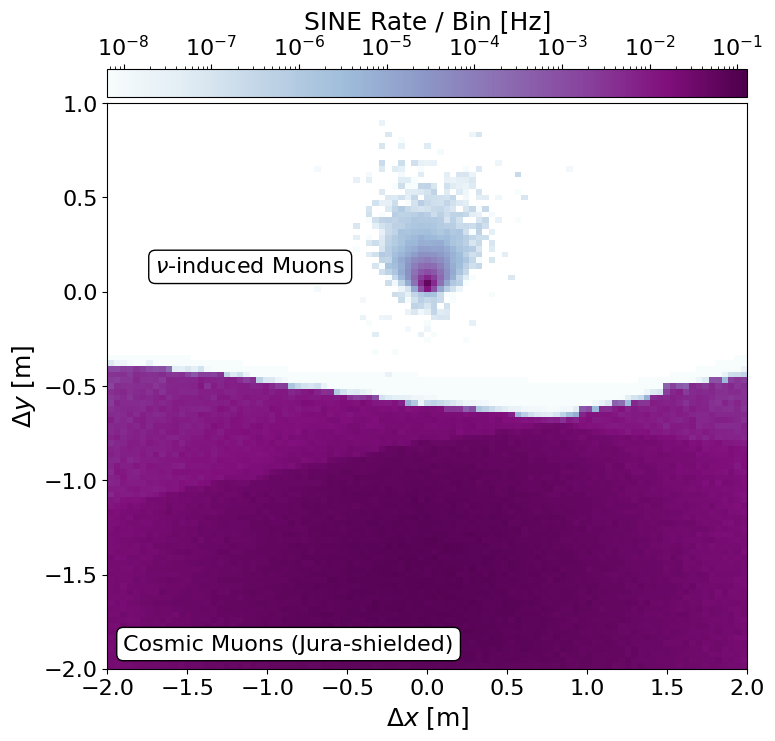

In [63]:
# ===== 2D spatial-displacement distribution (Jura-shielded cosmics vs neutrinos) =====
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(8, 8))
gs = gridspec.GridSpec(2, 1, height_ratios=[0.05, 1], hspace=0.02)
ax0 = fig.add_subplot(gs[1])
cax = fig.add_subplot(gs[0])

x_bins = np.linspace(-2, 2, 100)
y_bins = np.linspace(-2, 1, 100)
norm = LogNorm(vmin=1/n_seconds_HLLHC, vmax=2e7/n_seconds_HLLHC)
ax0.hist2d(cosmic["horizontal_displacement"], cosmic["vertical_displacement"], bins=(x_bins, y_bins),
           weights=cosmic["w"]*rate/Ngen, norm=norm)                       # Jura-shielded cosmics
nu_map = ax0.hist2d(nu_data["horizontal_displacement"], nu_data["vertical_displacement"],
                    bins=(x_bins, y_bins), weights=nu_data["weights"]/n_seconds_HLLHC, norm=norm)
fig.colorbar(nu_map[3], cax=cax, label="SINE Rate / Bin [Hz]", orientation="horizontal")
cax.xaxis.set_ticks_position("top"); cax.xaxis.set_label_position("top")

ax0.text(-1.9, -1.9, "Cosmic Muons (Jura-shielded)",fontsize=16,
         bbox=dict(facecolor="white", edgecolor="black", boxstyle="round"))
ax0.text(-1.7, 0.1, r"$\nu$-induced Muons",fontsize=16,
         bbox=dict(facecolor="white", edgecolor="black", boxstyle="round"))
ax0.set_xlabel(r"$\Delta x$ [m]")
ax0.set_ylabel(r"$\Delta y$ [m]")
plt.subplots_adjust(left=0.15, right=0.95, bottom=0.1, top=0.85, hspace=0.02)
plt.show()

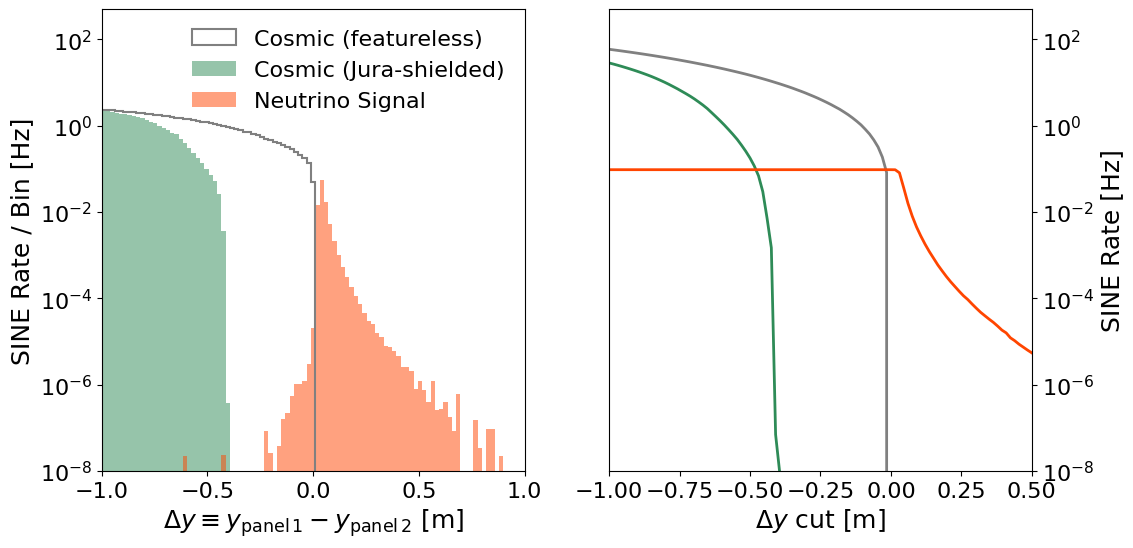

Conservative 1D (Dy>=-0.02): cosmic featureless 0.112 Hz -> Jura 0 Hz ;  nu 0.0951 Hz
Aggressive 1D (Dy>=+0.02): cosmic featureless 0 Hz -> Jura 0 Hz ;  nu 0.0934 Hz


In [ ]:
# ===== 1D vertical-cut study (Jura-shielded cosmics) =====
cosmic_tc = cosmic.query("delta_t > 8 and delta_t < 10")   # after the panel Delta-t cut
nu_tc     = nu_data.query("delta_t > 8 and delta_t < 10")
cut1D = 0.02
hist_bins = np.linspace(-1, 1, 100)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 6))

ax0.hist(cosmic_tc["muon_height_difference"], bins=hist_bins,
         weights=np.full(len(cosmic_tc), rate/Ngen),
         histtype="step", lw=1.5, color="grey", label="Cosmic (featureless)")
ax0.hist(cosmic_tc["muon_height_difference"], bins=hist_bins,
         weights=cosmic_tc["w"]*rate/Ngen,
         alpha=0.5, color=cosmic_color, label="Cosmic (Jura-shielded)")
ax0.hist(nu_tc["muon_height_difference"], bins=hist_bins,
         weights=nu_tc["weights"]/n_seconds_HLLHC,
         alpha=0.5, color=nu_color, label="Neutrino Signal")
#ax0.fill_between([cut1D, 0.1], [1, 1], color="black", alpha=0.1)
#ax0.axvline(cut1D, color="k", ls="--")
#ax0.text(0.06, 0.5, "Signal Region", fontsize=12, ha="center")
ax0.semilogy(); ax0.set_xlim(hist_bins[0], hist_bins[-1]); ax0.set_ylim(1e-8, 5e2)
ax0.set_xlabel(r"$\Delta y \equiv y_{\rm panel\,1} - y_{\rm panel\,2}$ [m]")
ax0.set_ylabel("SINE Rate / Bin [Hz]");
ax0.legend(loc="upper right")

# scan the 1D cut value
vc_arr = np.linspace(-1, 0.5, 100)
mhd_c, wc = cosmic_tc["muon_height_difference"].values, cosmic_tc["w"].values
mhd_n, wn = nu_tc["muon_height_difference"].values, nu_tc["weights"].values
bkg_feat = np.array([rate*(mhd_c >= vc).sum()/Ngen        for vc in vc_arr])
bkg_shld = np.array([rate*wc[mhd_c >= vc].sum()/Ngen      for vc in vc_arr])
sig      = np.array([wn[mhd_n > vc].sum()/n_seconds_HLLHC for vc in vc_arr])

ax1.plot(vc_arr, bkg_feat, color="grey",       label="Cosmic (featureless)")
ax1.plot(vc_arr, bkg_shld, color=cosmic_color,  label="Cosmic (Jura-shielded)")
ax1.plot(vc_arr, sig,      color=nu_color,      label=r"$\nu$-induced Muons")
#ax1.axvline(cut1D, color="k", ls="--", label="1D Cut")
ax1.semilogy(); ax1.set_xlim(vc_arr[0], vc_arr[-1]); ax1.set_ylim(1e-8, 5e2)
ax1.set_xlabel(r"$\Delta y$ cut [m]"); ax1.set_ylabel("SINE Rate [Hz]")
ax1.yaxis.tick_right(); ax1.yaxis.set_label_position("right")
plt.show()

for vc, name in [(-0.02, "Conservative 1D"), (0.02, "Aggressive 1D")]:
    sel = mhd_c >= vc
    print(f"{name} (Dy>={vc:+.2f}): cosmic featureless {rate*sel.sum()/Ngen:.3g} Hz "
          f"-> Jura {rate*wc[sel].sum()/Ngen:.3g} Hz ;  "
          f"nu {wn[mhd_n>vc].sum()/n_seconds_HLLHC:.3g} Hz")

## Summary

* The Jura overburden map (`overburden_horizon.csv`, ENU frame) was combined with a
  standard **Gaisser/Guan** sea-level muon flux and the project's **`muon_range`**
  energy-loss model (inverted to give the minimum surface energy `E_min(X)` needed to
  punch through a slant rock column `X`).
* Each coincidence muon from the featureless **EcoMug** sample (`MuonSimOut.txt`) was
  reweighted by the per-direction survival probability
  `w(θ_z, X) = ∫_{E_min}^∞ Φ dE / ∫_{E_thr}^∞ Φ dE`, after rotating its sky direction
  from the beam-aligned EcoMug frame into the ENU frame of the overburden map using the
  beam azimuth `α` (CMS → SINE bearing, CCW from East).
* The coincidence (both-panel) cosmic sample is strongly enriched near the horizon
  (panels separated *along* the beam), exactly the directions where the Jura provides
  overburden — so the shielding suppresses the cosmic rate at every cut stage by the
  factor reported in the table above.
* The azimuthal distribution w.r.t. the beam shows the Jura "shadow": cosmic muons
  arriving from the Jura azimuth band are removed, while the CMS/LHC direction (φ_beam = 0)
  is comparatively unshielded.

**Caveats.** The EcoMug sample was generated with EcoMug's `DefaultJ` flux, whereas the
survival fraction is computed with Gaisser/Guan; the two are similar power laws, so the
ratio `w` is a good approximation. `muon_range` is a simple CSDA-like model and the
overburden assumes uniform rock (ρ = 2.65 g/cm³); both are least accurate at the largest
column depths, which are already maximally suppressed.